## Topic: Random Variables

**The problem:** outcomes are often **words**, not numbers. A coin gives "Heads" or "Tails."
You can't do math with words — you can't average "Heads."

**The fix:** a **random variable** is just a rule that gives each outcome a **number**.

- Heads → **1**
- Tails → **0**

Now you can add them up, average them, do math.

**Two types:**
- **Discrete** = things you **count** (dice rolls, number of customers). Separate values with gaps.
- **Continuous** = things you **measure** (height, temperature). Any value, including decimals.

*(Note: the random variable gives us the VALUE. The probability is a separate number saying
how likely that value is.)*

In [1]:
# turn coin outcomes (words) into numbers
coin_flips = ["Heads", "Tails", "Heads", "Heads", "Tails"]

numbers = []                      # we will store the numbers here
for flip in coin_flips:           # look at each flip one by one
    if flip == "Heads":
        numbers.append(1)         # Heads becomes 1
    else:
        numbers.append(0)         # Tails becomes 0

print("outcomes:", coin_flips)
print("numbers :", numbers)
print("now we can add them:", sum(numbers), "heads")

outcomes: ['Heads', 'Tails', 'Heads', 'Heads', 'Tails']
numbers : [1, 0, 1, 1, 0]
now we can add them: 3 heads


## Topic: Probability Distributions

A **distribution** describes **how probability is spread across the possible values** of a
random variable — which values are likely, which are rare.

**Simple example — one die:** every value 1–6 has probability 1/6. Flat and even.

**Less simple — the total of two dice:** now it's uneven. There are more ways to make 7
than to make 2, so 7 is more likely. Plotted, it makes a little hill.

**Common shapes you should know:**
- **Uniform** — everything equally likely (a fair die)
- **Bernoulli** — ONE yes/no event (one coin flip)
- **Binomial** — MANY yes/no events, counting the yeses (heads in 10 flips)
- **Poisson** — how many events in a time window (customers per hour)
- **Normal (bell curve)** — most values near the middle, rare at the extremes ⭐ **the important one**

**The Normal / bell curve** is everywhere in ML. Two numbers describe it completely:
- **mean** = where the middle is
- **standard deviation** = how wide it is

In [2]:
# count all the ways to get each total with two dice
counts = {}                              # a dictionary to hold the counts

for die1 in range(1, 7):                 # die1 can be 1 to 6
    for die2 in range(1, 7):             # die2 can be 1 to 6
        total = die1 + die2
        if total in counts:
            counts[total] = counts[total] + 1
        else:
            counts[total] = 1

# there are 36 possible combinations in total (6 x 6)
print("total | probability")
for total in sorted(counts):
    probability = counts[total] / 36
    print(total, "    |", round(probability, 4))

total | probability
2     | 0.0278
3     | 0.0556
4     | 0.0833
5     | 0.1111
6     | 0.1389
7     | 0.1667
8     | 0.1389
9     | 0.1111
10     | 0.0833
11     | 0.0556
12     | 0.0278


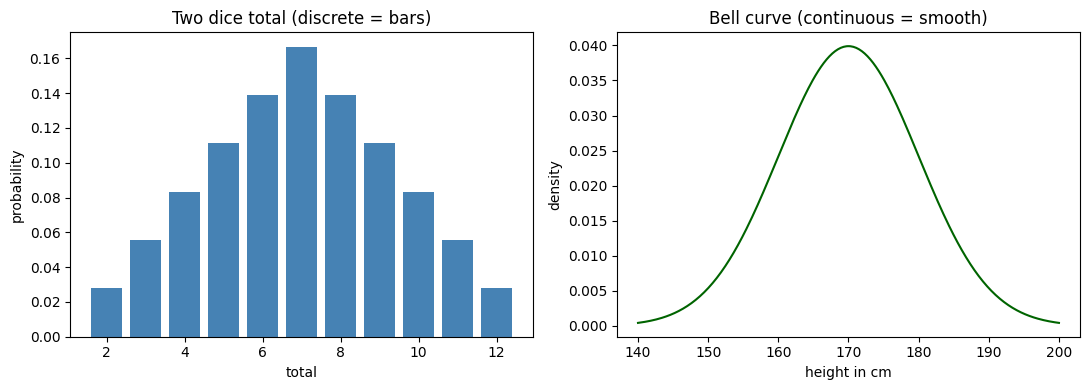

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# make the dice-total distribution into lists we can plot
totals = sorted(counts)
probabilities = []
for t in totals:
    probabilities.append(counts[t] / 36)

plt.figure(figsize=(11, 4))

# left: the dice total distribution (discrete = bars)
plt.subplot(1, 2, 1)
plt.bar(totals, probabilities, color="steelblue")
plt.title("Two dice total (discrete = bars)")
plt.xlabel("total")
plt.ylabel("probability")

# right: a bell curve (continuous = smooth curve)
plt.subplot(1, 2, 2)
x_values = np.linspace(140, 200, 300)          # heights from 140 to 200 cm
mean = 170
std = 10
bell = (1/(std*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_values-mean)/std)**2)
plt.plot(x_values, bell, color="darkgreen")
plt.title("Bell curve (continuous = smooth)")
plt.xlabel("height in cm")
plt.ylabel("density")

plt.tight_layout()
plt.show()

## Topic : Expected Value & Variance

Any distribution can be summarized by **two numbers**.

### Expected value (the center) = the "mean"
The **average outcome if you repeated it many, many times.**
How to get it: multiply each value by its probability, then add them all up.

For a die: (1+2+3+4+5+6)/6 = **3.5**

**Funny thing:** you can never roll a 3.5! Expected value isn't the most likely outcome —
it's the **long-run average**. Think of it as the balance point of the distribution.

### Variance (the spread)
How **spread out** the values are — how far they typically land from the center.
- Small variance = values huddle near the average (predictable)
- Large variance = values scatter widely (unpredictable)

How to get it: for each value, measure the distance from the mean, **square it**, then average.
*(We square so the +'s and −'s don't cancel out to zero.)*

### Standard deviation
Variance has squared units (weird to read). Take the **square root** and you get the
**standard deviation** — back in normal units, so you can actually interpret it.

### Why you need BOTH
- **Investment A:** returns 5% every year → average 5%
- **Investment B:** +55%, then −45%, then +55%... → average also ~5%

**Same average, totally different experience!** A is calm, B is a rollercoaster.
The average alone hides that. **Variance is what tells them apart.**

*(In finance: mean = expected return, variance = risk. That's the whole tradeoff.)*

In [5]:
# Expected value of a die roll
values = [1, 2, 3, 4, 5, 6]
prob_each = 1/6

expected = 0
for v in values:
    expected = expected + v * prob_each      # value times its probability
print("expected value (mean) =", expected)

# Variance of a die roll
variance = 0
for v in values:
    distance = v - expected                   # how far from the mean
    variance = variance + (distance * distance) * prob_each   # squared, times probability
print("variance =", round(variance, 4))
print("standard deviation =", round(variance ** 0.5, 4))

expected value (mean) = 3.5
variance = 2.9167
standard deviation = 1.7078


In [6]:
# two investments with the SAME average but very different spread
investment_a = [5, 5, 5, 5]              # steady
investment_b = [55, -45, 55, -45]        # rollercoaster

def mean_of(numbers):
    total = 0
    for n in numbers:
        total = total + n
    return total / len(numbers)

def variance_of(numbers):
    m = mean_of(numbers)
    total = 0
    for n in numbers:
        total = total + (n - m) ** 2
    return total / len(numbers)

print("Investment A -> mean:", mean_of(investment_a), " variance:", variance_of(investment_a))
print("Investment B -> mean:", mean_of(investment_b), " variance:", variance_of(investment_b))
print("\nSame mean, but B's variance is huge. The mean alone would have fooled us!")

Investment A -> mean: 5.0  variance: 0.0
Investment B -> mean: 5.0  variance: 2500.0

Same mean, but B's variance is huge. The mean alone would have fooled us!


## Topic 8: Probability Density (and why we need AREA)

**A puzzle:** what's the probability someone is **exactly 170 cm**?
Not 170.1. Not 170.0001. *Exactly* 170.000000... forever.

**Answer: essentially zero.** Nobody is exactly that, to infinite decimals. And that's true
for *every* exact value! So how does probability work for continuous things at all?

**The fix: ask about RANGES, not exact values.**
"What's the probability someone is between 169 and 171 cm?" — *that* has a real answer.

### And ranges are measured by AREA under the curve
Draw the bell curve of heights. The **slice of area** between 169 and 171 **IS** the probability.
- Wide slice near the peak → big area → high probability
- Thin slice in the tail → small area → low probability
- The **whole area** under the curve = **1** (everyone has *some* height)

**Why an exact value is zero, now obvious:** a single point has **no width** → no area → no probability.

### Height of the curve = "density", not probability
The curve's height tells you how **densely packed** probability is around there — like
population density on a map. Density at a single point doesn't give you people; density
**over a region** does. Same here: density × width = area = probability.

### 🌉 The bridge to calculus
**Area under a curve = an integral.** So:
$$P(a \le X \le b) = \int_a^b f(x)\,dx$$

This is the one reason integrals were on the calculus list — **area = probability**.

In [9]:

# simulate 100,000 people's heights: average 170 cm, spread 10 cm
heights = np.random.normal(170, 10, 100000)

# count how many fall in the RANGE 169 to 171
in_range = 0
for h in heights:
    if h >= 169 and h <= 171:
        in_range = in_range + 1

print("people between 169 and 171 cm:", in_range)
print("fraction (= the probability) :", round(in_range/100000, 4))

# now count how many are EXACTLY 170.0
exactly_170 = 0
for h in heights:
    if h == 170.0:
        exactly_170 = exactly_170 + 1

print("\npeople EXACTLY 170.0 cm:", exactly_170)
print("-> zero! An exact value has no width, so no area, so no probability.")

people between 169 and 171 cm: 7826
fraction (= the probability) : 0.0783

people EXACTLY 170.0 cm: 0
-> zero! An exact value has no width, so no area, so no probability.


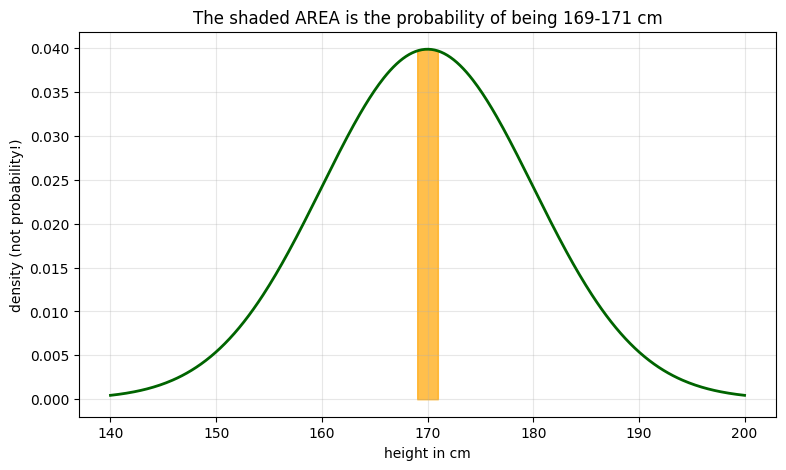

In [10]:
import matplotlib.pyplot as plt

x_values = np.linspace(140, 200, 400)
mean = 170
std = 10
curve = (1/(std*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_values-mean)/std)**2)

plt.figure(figsize=(9, 5))
plt.plot(x_values, curve, color="darkgreen", linewidth=2)

# shade the area between 169 and 171 -- THAT shaded area is the probability
plt.fill_between(x_values, curve, where=(x_values >= 169) & (x_values <= 171),
                 color="orange", alpha=0.7)

plt.title("The shaded AREA is the probability of being 169-171 cm")
plt.xlabel("height in cm")
plt.ylabel("density (not probability!)")
plt.grid(alpha=0.3)
plt.show()